In [31]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]=T[1] # Left boundary
    T[-1]=T[-2]**2/max(T[-3],1e-40) # Right boundary

def solve_two_layer_FTCS(k1, k2, z_dis,Pda,Lz,nz,tf,device):
    # Construct numerical grid
    dz = Lz/nz; z = torch.arange(-0.5, nz+1, device=device)*dz
    # Finite volume, *** z_dis is at a cell boundary ***
    # need one more point at each end, *** size of z = (nz+2) ***

    # Make sure we reach tf in integer number of setps
    dt = 0.5*(dz**2)/max(k1, k2) # need to include k1 and k2 in dt
    nt = int(np.ceil(tf/dt)); dt = tf/nt # need to uopdate dt 
    print(f'nz = {nz}, nt = {nt}; alignment of nt*dt with tf: err = {nt*dt-tf}')
    
    # Find index m such that z[m+1] > z_dis
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    # no need to move a scalar between gpu and cpu?
    # check z[m+1/2]=z_dis?
    print(f'alignment of cell boundary with z_dis: err = {z[m]+0.5*dz-z_dis}')
    
    # Harmonic mean of k at z_dis
    k_interface = 2 * k1 * k2 / (k1 + k2)
    # Precompute kh (effective k at half grid point z_{j+1/2})
    kh = torch.where(z[:-1] < z_dis, k1, k2); kh[m] = k_interface
    # *** size of kh = (nz+1) ***
    # Pytorch will automatically use the device and dtype of z
    
    # Source at internal points, *** size of source = nz ***
    source = Pda * torch.exp(-z[1:-1])

    # Need to pre-allocate T and J
    T = torch.zeros(nz+2, device=device) # size of T = nz+2
    Jh = torch.zeros(nz+1, device=device) # size of k = nz+1
    
    # advance in time steps
    for tstep in range(nt):
        # FTCS update
        set_BCs(T) # start each step by enforcing BCs
        Jh = -kh * (T[1:]-T[:-1])/dz # Flux 
        T[1:-1] = T[1:-1] + dt/dz*(Jh[:-1] - Jh[1:])+dt*source
    set_BCs(T) # at the end enforce BC again
    
    # Map T to Th (T at half grid points z_{j+1/2}); This mapping is necessary 
    # because coarse grid and fine grid do not share any common cell centers!!!
    zh = 0.5*(z[:-1]+z[1:])
    Th = 0.5*(T[:-1]+T[1:]); Th[m]=T[m]+0.5*(T[m+1]-T[m])*k_interface/k1
    return z, T, zh, Th


In [1]:
device = 'cpu'
k1 = 1.0; k2 = 2.0; z_dis = 0.50; Pda = 1.0; tf = 2.0
Lz = 10.0; nz_unit = 30; nz = int(Lz) * nz_unit

Delta_d = 1.0 / 4.0   # chosen so n_sub_t ≈ nz

z, zh, t_out, U = solve_two_layer_CN(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device)
print(f'U shape: {U.shape}')   # should be (nz+2, nt) ≈ square

NameError: name 'solve_two_layer_CN' is not defined

In [33]:
# just for scaling to S 
nt = len(zh1); dt = tf/nt
t = torch.arange(dt, nt+1, device=device)*dt
t.shape
s  = torch.exp(-z1*(z1+1)/(2*t+z1+1))
tau = 1/(1+t)
print(tau)

tensor([1.0000, 0.9934, 0.9868, 0.9804, 0.9741, 0.9678, 0.9616, 0.9555, 0.9495,
        0.9435, 0.9377, 0.9319, 0.9261, 0.9205, 0.9149, 0.9093, 0.9039, 0.8985,
        0.8931, 0.8879, 0.8827, 0.8775, 0.8724, 0.8674, 0.8624, 0.8575, 0.8527,
        0.8479, 0.8431, 0.8384, 0.8338, 0.8292, 0.8246, 0.8201, 0.8157, 0.8113,
        0.8069, 0.8026, 0.7984, 0.7942, 0.7900, 0.7859, 0.7818, 0.7778, 0.7738,
        0.7698, 0.7659, 0.7620, 0.7582, 0.7544, 0.7506, 0.7469, 0.7432, 0.7395,
        0.7359, 0.7323, 0.7288, 0.7253, 0.7218, 0.7184, 0.7149, 0.7116, 0.7082,
        0.7049, 0.7016, 0.6984, 0.6951, 0.6919, 0.6888, 0.6856, 0.6825, 0.6794,
        0.6764, 0.6734, 0.6704, 0.6674, 0.6644, 0.6615, 0.6586, 0.6558, 0.6529,
        0.6501, 0.6473, 0.6445, 0.6418, 0.6390, 0.6363, 0.6337, 0.6310, 0.6284,
        0.6258, 0.6232, 0.6206, 0.6181, 0.6155, 0.6130, 0.6105, 0.6081, 0.6056,
        0.6032, 0.6008, 0.5984, 0.5960, 0.5937, 0.5913, 0.5890, 0.5867, 0.5845,
        0.5822, 0.5799, 0.5777, 0.5755, 

In [34]:
W = T1/tf # T1(z) at tf = 2

In [35]:
T1.shape

torch.Size([302])

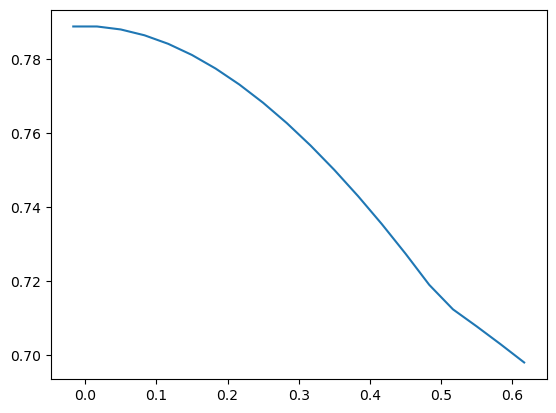

In [36]:
plt.plot(z1[:20],T1[:20])

In [1]:
kratio = torch.ones(len(s))*(k1/k2)
z_disv = torch.ones(len(s))*z_dis
tv = torch.ones(len(s))*tf

NameError: name 'torch' is not defined

In [38]:
train = torch.stack([s, tv, kratio, z_disv], dim=-1)
W = W.reshape(nz1+2,1)
W.shape

torch.Size([302, 1])

In [41]:
data_to_save = {
        's': s,
        'z1':z1,
        'tv': tv,
        'W': W,
        'kratio': kratio,
        'z_disv': z_disv
    }
outfile = f'./train/caseA_nt{nt}_nz{nz1}_zc{z_dis}.pt'
torch.save(data_to_save,outfile)
print(f'Saved to {outfile}')

Saved to ./train/caseA_nt301_nz300_zc0.5.pt
